# Probability for Machine Learning
### Quantifying Uncertainty

Machine learning models are never 100% certain. Probability is the mathematical language we use to quantify that uncertainty.

A classification model doesn't just say **'This is a cat'** — it says:
```
P(class=cat | image) = 0.95
```
*'Given the image, I am 95% confident this is a cat.'*

| Topic | Why it matters in ML |
|---|---|
| Probability Basics | Foundation of all probabilistic models |
| Random Variables | How we represent uncertain quantities |
| Distributions | How data is shaped (Gaussian, Bernoulli) |
| Bayes' Theorem | Core of probabilistic inference |
| Naive Bayes | A real classifier built from Bayes' theorem |
| Entropy & KL Divergence | Used in loss functions (cross-entropy loss) |

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, bernoulli
from collections import Counter

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100

---
## 1. Probability Basics

Probability measures **how likely an event is**, on a scale from 0 (impossible) to 1 (certain).

### Three rules everything builds on:

| Rule | Formula | Meaning |
|---|---|---|
| **Sum rule** | `P(A) = Σ P(A, B)` | Marginalize over all values of B |
| **Product rule** | `P(A, B) = P(A) · P(B\|A)` | Joint = marginal × conditional |
| **Complement** | `P(not A) = 1 - P(A)` | Probabilities sum to 1 |

### Joint vs Marginal vs Conditional
```
P(A, B)   → Joint:       probability of A AND B happening together
P(A)      → Marginal:    probability of A regardless of B
P(A | B)  → Conditional: probability of A GIVEN that B already happened
```

In [4]:
# Simulate a simple dataset: Spam classifier
# Each email is (spam=1/0, contains_word_FREE=1/0)
emails = [
    (1, 1), (1, 1), (1, 0), (1, 1), (1, 0),   # spam emails
    (0, 0), (0, 0), (0, 1), (0, 0), (0, 0),   # not spam
]

n = len(emails)
spam       = [e for e in emails if e[0] == 1]
has_free   = [e for e in emails if e[1] == 1]
spam_free  = [e for e in emails if e[0] == 1 and e[1] == 1]

P_spam          = len(spam) / n
P_free          = len(has_free) / n
P_spam_and_free = len(spam_free) / n
P_free_given_spam = len(spam_free) / len(spam)

print(f'P(spam)              = {P_spam}       ← marginal')
print(f'P(FREE)              = {P_free}       ← marginal')
print(f'P(spam AND FREE)     = {P_spam_and_free}      ← joint')
print(f'P(FREE | spam)       = {P_free_given_spam}      ← conditional')
print()
# Verify product rule: P(A,B) = P(B|A) * P(A)
print('Product rule check:',
      P_free_given_spam * P_spam, '==', P_spam_and_free)

P(spam)              = 0.5       ← marginal
P(FREE)              = 0.4       ← marginal
P(spam AND FREE)     = 0.3      ← joint
P(FREE | spam)       = 0.6      ← conditional

Product rule check: 0.3 == 0.3


---
## 2. Random Variables

A **random variable** is a variable whose value is the outcome of a random experiment.

```
X = outcome of rolling a die  → X ∈ {1, 2, 3, 4, 5, 6}
Y = height of a random person → Y ∈ any real number
```

| Type | Description | Example in ML |
|---|---|---|
| **Discrete** | Countable outcomes | Class label (0 or 1) |
| **Continuous** | Any value in a range | Pixel intensity, weight |

### Key statistics
- **Mean (μ):** Expected value — center of the distribution
- **Variance (σ²):** How spread out values are around the mean
- **Standard Deviation (σ):** Square root of variance — same units as data

=== Discrete: Die Roll ===
Counts: {np.int64(1): 1019, np.int64(2): 965, np.int64(3): 983, np.int64(4): 1009, np.int64(5): 1024, np.int64(6): 1000}
Mean   : 3.509  (expected: 3.5)
Std Dev: 1.712

=== Continuous: House Prices ===
Mean   : $298,091
Std Dev: $50,003
Variance: $2,500,292,298


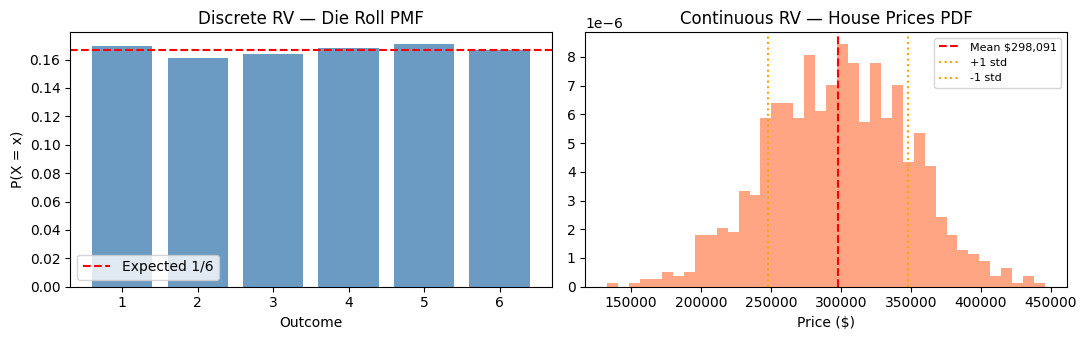

In [5]:
# Discrete: die roll
die_rolls = np.random.randint(1, 7, size=6000)
print('=== Discrete: Die Roll ===')
print('Counts:', dict(sorted(Counter(die_rolls).items())))
print(f'Mean   : {die_rolls.mean():.3f}  (expected: 3.5)')
print(f'Std Dev: {die_rolls.std():.3f}')

# Continuous: house prices
prices = np.random.normal(300_000, 50_000, 1000)   # mean=300k, std=50k
print('\n=== Continuous: House Prices ===')
print(f'Mean   : ${prices.mean():,.0f}')
print(f'Std Dev: ${prices.std():,.0f}')
print(f'Variance: ${prices.var():,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(range(1, 7), [np.sum(die_rolls==i)/len(die_rolls) for i in range(1,7)],
            color='steelblue', alpha=0.8)
axes[0].axhline(1/6, color='red', linestyle='--', label='Expected 1/6')
axes[0].set_title('Discrete RV — Die Roll PMF')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('P(X = x)')
axes[0].legend()

axes[1].hist(prices, bins=40, density=True, alpha=0.7, color='coral')
axes[1].axvline(prices.mean(), color='red', linestyle='--', label=f'Mean ${prices.mean():,.0f}')
axes[1].axvline(prices.mean()+prices.std(), color='orange', linestyle=':', label='+1 std')
axes[1].axvline(prices.mean()-prices.std(), color='orange', linestyle=':', label='-1 std')
axes[1].set_title('Continuous RV — House Prices PDF')
axes[1].set_xlabel('Price ($)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 3. Probability Distributions

### 3a. Gaussian (Normal) Distribution
The most important distribution in ML. Appears naturally in data due to the **Central Limit Theorem**.

$$
\mathcal{N}(x; \mu, \sigma^2) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

Used in: Linear Regression (noise assumption), Gaussian Naive Bayes, GMMs, VAEs.

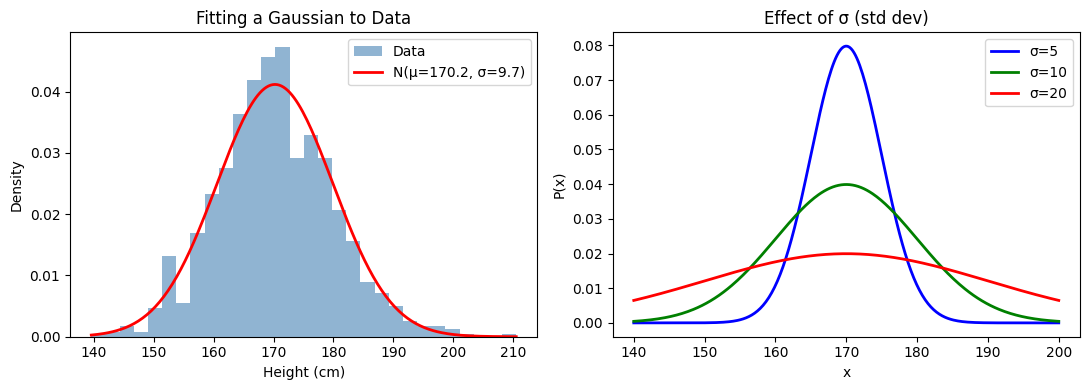

68% of data falls within:  160.5 – 179.9 cm  (μ ± 1σ)
95% of data falls within:  150.9 – 189.6 cm  (μ ± 2σ)
99.7% of data falls within: 141.2 – 199.3 cm  (μ ± 3σ)


In [6]:
heights = np.random.normal(170, 10, 1000)  # mean=170cm, std=10

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Fit
mu, std = norm.fit(heights)
x = np.linspace(heights.min(), heights.max(), 200)

axes[0].hist(heights, bins=30, density=True, alpha=0.6, color='steelblue', label='Data')
axes[0].plot(x, norm.pdf(x, mu, std), 'r-', lw=2, label=f'N(μ={mu:.1f}, σ={std:.1f})')
axes[0].set_title('Fitting a Gaussian to Data')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Effect of changing σ
x2 = np.linspace(140, 200, 300)
for sigma, color in [(5, 'blue'), (10, 'green'), (20, 'red')]:
    axes[1].plot(x2, norm.pdf(x2, 170, sigma), lw=2, color=color, label=f'σ={sigma}')
axes[1].set_title('Effect of σ (std dev)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('P(x)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'68% of data falls within:  {mu-std:.1f} – {mu+std:.1f} cm  (μ ± 1σ)')
print(f'95% of data falls within:  {mu-2*std:.1f} – {mu+2*std:.1f} cm  (μ ± 2σ)')
print(f'99.7% of data falls within: {mu-3*std:.1f} – {mu+3*std:.1f} cm  (μ ± 3σ)')

### 3b. Bernoulli Distribution
Models a **binary outcome**: success (1) or failure (0) with probability `p`.

$$P(X=x) = p^x (1-p)^{1-x}, \quad x \in \{0,1\}$$

Used in: Binary classification output, logistic regression, spam detection.

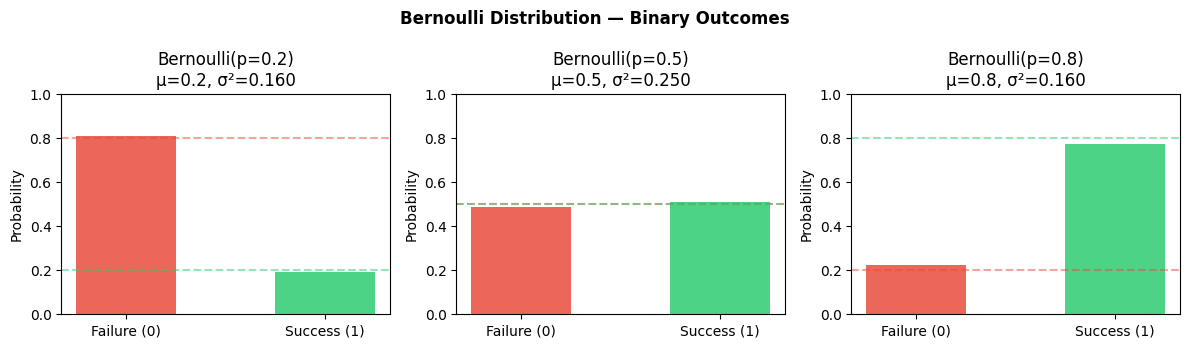

In logistic regression, the output is P(y=1|x) — a Bernoulli probability.
If P(y=1|x) > 0.5  →  predict class 1
If P(y=1|x) < 0.5  →  predict class 0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, p in zip(axes, [0.2, 0.5, 0.8]):
    samples = bernoulli.rvs(p, size=500)
    counts = [np.mean(samples == 0), np.mean(samples == 1)]
    bars = ax.bar([0, 1], counts, color=['#e74c3c', '#2ecc71'], alpha=0.85, width=0.5)
    ax.axhline(1-p, color='#e74c3c', linestyle='--', alpha=0.5)
    ax.axhline(p,   color='#2ecc71', linestyle='--', alpha=0.5)
    ax.set_title(f'Bernoulli(p={p})\nμ={p}, σ²={p*(1-p):.3f}')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Failure (0)', 'Success (1)'])
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)

plt.suptitle('Bernoulli Distribution — Binary Outcomes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('In logistic regression, the output is P(y=1|x) — a Bernoulli probability.')
print('If P(y=1|x) > 0.5  →  predict class 1')
print('If P(y=1|x) < 0.5  →  predict class 0')

---
## 4. Bayes' Theorem

The most important equation in probabilistic ML:

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

| Term | Name | Meaning |
|---|---|---|
| `P(A)` | **Prior** | What we believe *before* seeing data |
| `P(B\|A)` | **Likelihood** | How probable is the data given A is true |
| `P(B)` | **Evidence** | Total probability of observing B (normalizer) |
| `P(A\|B)` | **Posterior** | Updated belief *after* seeing data |

> **Learning = updating the prior with evidence to get the posterior.**

In [8]:
# Classic example: Medical test for a disease
# Disease prevalence: 1% of population
# Test sensitivity: P(positive | disease)  = 99%
# Test specificity: P(negative | no disease) = 95%  → false positive rate = 5%

P_disease    = 0.01          # prior: 1% have the disease
P_no_disease = 1 - P_disease

P_pos_given_disease    = 0.99   # sensitivity
P_pos_given_no_disease = 0.05   # false positive rate

# P(positive) via sum rule (law of total probability)
P_positive = (P_pos_given_disease * P_disease +
              P_pos_given_no_disease * P_no_disease)

# Bayes' theorem: P(disease | positive test)
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_positive

print('=== Medical Test — Bayes\' Theorem ===')
print(f'Prior P(disease)           = {P_disease:.0%}')
print(f'P(positive | disease)      = {P_pos_given_disease:.0%}  ← sensitivity')
print(f'P(positive | no disease)   = {P_pos_given_no_disease:.0%}  ← false positive rate')
print(f'P(positive)                = {P_positive:.4f}  ← evidence')
print()
print(f'>>> P(disease | positive test) = {P_disease_given_pos:.2%} <<<')
print()
print('Intuition: Even with a 99% accurate test, only ~16% of positive')
print('results are true disease — because the disease is so rare (1%).')
print('This is why priors matter enormously!')

=== Medical Test — Bayes' Theorem ===
Prior P(disease)           = 1%
P(positive | disease)      = 99%  ← sensitivity
P(positive | no disease)   = 5%  ← false positive rate
P(positive)                = 0.0594  ← evidence

>>> P(disease | positive test) = 16.67% <<<

Intuition: Even with a 99% accurate test, only ~16% of positive
results are true disease — because the disease is so rare (1%).
This is why priors matter enormously!


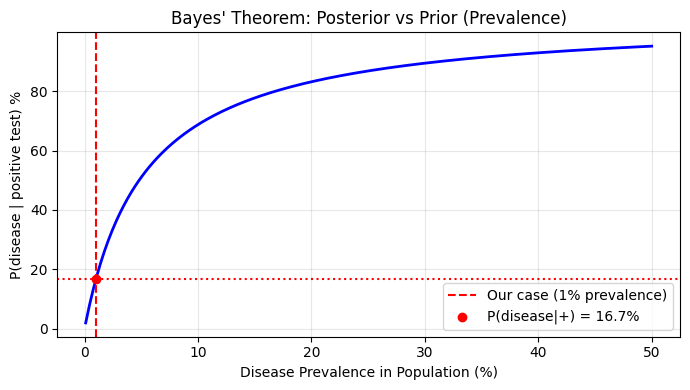

In [9]:
# Visualize: how posterior changes as prevalence changes
prevalences = np.linspace(0.001, 0.5, 300)
posteriors = []
for prev in prevalences:
    p_pos = P_pos_given_disease * prev + P_pos_given_no_disease * (1 - prev)
    posteriors.append(P_pos_given_disease * prev / p_pos)

plt.figure(figsize=(7, 4))
plt.plot(prevalences * 100, [p * 100 for p in posteriors], 'b-', lw=2)
plt.axvline(1, color='red', linestyle='--', label='Our case (1% prevalence)')
plt.axhline(P_disease_given_pos * 100, color='red', linestyle=':')
plt.scatter([1], [P_disease_given_pos * 100], color='red', zorder=5,
            label=f'P(disease|+) = {P_disease_given_pos:.1%}')
plt.xlabel('Disease Prevalence in Population (%)')
plt.ylabel('P(disease | positive test) %')
plt.title("Bayes' Theorem: Posterior vs Prior (Prevalence)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Naive Bayes Classifier

A real ML classifier built directly from Bayes' theorem.

**Key idea:** To classify an email with features (words) `x₁, x₂, ..., xₙ`:

$$P(\text{spam} \mid x_1,...,x_n) \propto P(\text{spam}) \cdot \prod_{i=1}^n P(x_i \mid \text{spam})$$

The **"naive"** assumption: each feature (word) is **independent** given the class.  
This is rarely true, but works surprisingly well in practice.

### Steps:
1. Estimate **priors**: how common is each class?
2. Estimate **likelihoods**: given the class, how common is each feature?
3. Apply Bayes' theorem to get the **posterior** for a new example
4. Predict the class with the **highest posterior**

In [10]:
# ── Naive Bayes from scratch (no sklearn) ────────────────────────────────────

# Training data: emails with 3 features
# Features: [contains 'FREE', contains 'WINNER', contains 'meeting']
# Label: 1 = spam, 0 = not spam

X_train = np.array([
    [1, 1, 0],  # spam
    [1, 0, 0],  # spam
    [1, 1, 0],  # spam
    [0, 1, 0],  # spam
    [1, 0, 0],  # spam
    [0, 0, 1],  # not spam
    [0, 0, 0],  # not spam
    [0, 0, 1],  # not spam
    [0, 1, 1],  # not spam
    [0, 0, 0],  # not spam
])
y_train = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])
features = ['FREE', 'WINNER', 'meeting']

# Step 1: Priors
P_spam     = np.mean(y_train == 1)
P_not_spam = np.mean(y_train == 0)

# Step 2: Likelihoods P(feature=1 | class)
# Add-1 (Laplace) smoothing to avoid zero probabilities
spam_emails     = X_train[y_train == 1]
not_spam_emails = X_train[y_train == 0]

lhood_spam     = (spam_emails.sum(axis=0) + 1) / (len(spam_emails) + 2)
lhood_not_spam = (not_spam_emails.sum(axis=0) + 1) / (len(not_spam_emails) + 2)

print('=== Learned Parameters ===')
print(f'P(spam)     = {P_spam:.2f}  |  P(not spam) = {P_not_spam:.2f}')
print()
print('Likelihoods P(word | class):')
for i, word in enumerate(features):
    print(f'  P({word:7} | spam)     = {lhood_spam[i]:.2f}')
    print(f'  P({word:7} | not spam) = {lhood_not_spam[i]:.2f}')
    print()

# Step 3 & 4: Classify a new email [FREE=1, WINNER=1, meeting=0]
new_email = np.array([1, 1, 0])

log_prob_spam     = np.log(P_spam)
log_prob_not_spam = np.log(P_not_spam)

for i, feat in enumerate(new_email):
    if feat == 1:
        log_prob_spam     += np.log(lhood_spam[i])
        log_prob_not_spam += np.log(lhood_not_spam[i])

prediction = 'SPAM' if log_prob_spam > log_prob_not_spam else 'NOT SPAM'
print('=== Classify New Email: [FREE=✓, WINNER=✓, meeting=✗] ===')
print(f'log P(spam | email)     = {log_prob_spam:.4f}')
print(f'log P(not spam | email) = {log_prob_not_spam:.4f}')
print(f'>>> Prediction: {prediction} <<<')

=== Learned Parameters ===
P(spam)     = 0.50  |  P(not spam) = 0.50

Likelihoods P(word | class):
  P(FREE    | spam)     = 0.71
  P(FREE    | not spam) = 0.14

  P(WINNER  | spam)     = 0.57
  P(WINNER  | not spam) = 0.29

  P(meeting | spam)     = 0.14
  P(meeting | not spam) = 0.57

=== Classify New Email: [FREE=✓, WINNER=✓, meeting=✗] ===
log P(spam | email)     = -1.5892
log P(not spam | email) = -3.8918
>>> Prediction: SPAM <<<


In [11]:
# ── Same thing with sklearn ─────────────────────────────────────────────────
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report

nb = BernoulliNB()
nb.fit(X_train, y_train)

new_email_2d = new_email.reshape(1, -1)
pred  = nb.predict(new_email_2d)[0]
proba = nb.predict_proba(new_email_2d)[0]

print('=== sklearn BernoulliNB ===')
print(f'Prediction           : {"SPAM" if pred == 1 else "NOT SPAM"}')
print(f'P(not spam | email)  : {proba[0]:.4f}')
print(f'P(spam | email)      : {proba[1]:.4f}')
print()

# Training accuracy
print(classification_report(y_train, nb.predict(X_train),
                             target_names=['Not Spam', 'Spam']))

=== sklearn BernoulliNB ===
Prediction           : SPAM
P(not spam | email)  : 0.0476
P(spam | email)      : 0.9524

              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00         5
        Spam       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



---
## 6. Entropy & KL Divergence *(bonus — used in Loss Functions)*

### Entropy
Measures **uncertainty** in a distribution. High entropy = more uncertainty.

$$H(P) = -\sum_i P(x_i) \log P(x_i)$$

### KL Divergence
Measures **how different** two distributions are. Used heavily in VAEs, RL.

$$D_{KL}(P \| Q) = \sum_i P(x_i) \log \frac{P(x_i)}{Q(x_i)}$$

### Cross-Entropy Loss
The loss function for classification is literally cross-entropy between true labels and predictions:

$$\mathcal{L} = -\sum_i y_i \log(\hat{y}_i)$$

=== Entropy ===
Certain  [1.0, 0.0]  →  H = -0.0000 bits
Biased   [0.9, 0.1]   →  H = 0.4690 bits
Uniform  [0.5, 0.5]   →  H = 1.0000 bits  ← max uncertainty

=== Cross-Entropy Loss ===
Good prediction [0.95 0.05]  →  Loss = 0.0513
Bad  prediction [0.05 0.95]   →  Loss = 2.9957
Higher loss = worse prediction. Training minimizes this.


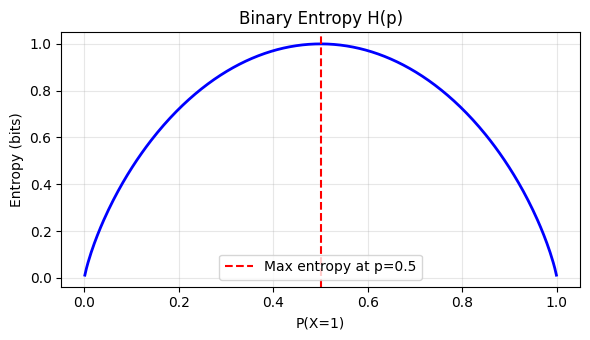

In [12]:
def entropy(p):
    p = np.array(p)
    p = p[p > 0]   # avoid log(0)
    return -np.sum(p * np.log2(p))

def cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)  # avoid log(0)
    return -np.sum(y_true * np.log(y_pred))

# Entropy examples
certain   = [1.0, 0.0]          # always class 0 → zero uncertainty
uncertain = [0.5, 0.5]          # 50/50 → maximum uncertainty
biased    = [0.9, 0.1]

print('=== Entropy ===')
print(f'Certain  {certain}  →  H = {entropy(certain):.4f} bits')
print(f'Biased   {biased}   →  H = {entropy(biased):.4f} bits')
print(f'Uniform  {uncertain}   →  H = {entropy(uncertain):.4f} bits  ← max uncertainty')

# Cross-entropy loss in action
print('\n=== Cross-Entropy Loss ===')
y_true = np.array([1, 0])              # true label: class 0
good_pred = np.array([0.95, 0.05])     # confident and correct
bad_pred  = np.array([0.05, 0.95])     # confident but wrong

print(f'Good prediction {good_pred}  →  Loss = {cross_entropy(y_true, good_pred):.4f}')
print(f'Bad  prediction {bad_pred}   →  Loss = {cross_entropy(y_true, bad_pred):.4f}')
print('Higher loss = worse prediction. Training minimizes this.')

# Visualize entropy across p values
p_vals = np.linspace(0.001, 0.999, 300)
h_vals = [-p*np.log2(p) - (1-p)*np.log2(1-p) for p in p_vals]

plt.figure(figsize=(6, 3.5))
plt.plot(p_vals, h_vals, 'b-', lw=2)
plt.axvline(0.5, color='red', linestyle='--', label='Max entropy at p=0.5')
plt.xlabel('P(X=1)')
plt.ylabel('Entropy (bits)')
plt.title('Binary Entropy H(p)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

| Concept | Formula | Where it appears in ML |
|---|---|---|
| **Conditional prob** | `P(A\|B) = P(A,B)/P(B)` | Every classifier |
| **Gaussian** | `N(μ, σ²)` | Linear regression, Naive Bayes, VAEs |
| **Bernoulli** | `p^x (1-p)^(1-x)` | Logistic regression output |
| **Bayes' theorem** | `P(A\|B) ∝ P(B\|A)·P(A)` | Bayesian inference, Naive Bayes |
| **Naive Bayes** | `P(y\|x) ∝ P(y)·∏P(xᵢ\|y)` | Text classification, spam filters |
| **Cross-entropy** | `-Σ y log ŷ` | Classification loss function |

### What to learn next
- **Maximum Likelihood Estimation (MLE)** — how parameters are learned from data  
- **Logistic Regression** — Bernoulli + Bayes applied to binary classification  
- **Gaussian Mixture Models** — clustering using Gaussian distributions